# Task 1: Multi-Class Classification - Baseline DeepLense Classification

### Objective
Establish a strong, data-driven baseline for classifying strong gravitational lensing images into three distinct dark matter substructure categories: **No Substructure**, **Subhalo**, and **Vortex**. 

### The Approach
For this baseline evaluation, we treat the lensing classification as a standard computer vision problem, relying purely on spatial pattern recognition.
* **Architecture:** We utilize a pre-trained **EfficientNet-B2** (implemented via the `timm` library) adapted for single-channel (grayscale) inputs. EfficientNet was selected for its compound scaling strategy; it provides an optimal balance of parameter efficiency and deep feature extraction, making it highly capable of detecting the subtle flux anomalies in 150x150 lensing images without requiring massive computational overhead.
* **Objective:** The network is optimized using Standard Cross-Entropy Loss to map the raw pixel intensities directly to discrete class probabilities. 
* **Why this matters:** Establishing this purely data-driven baseline is critical. It provides the exact performance threshold (ROC-AUC and Accuracy) that our subsequent physics-guided models (Task 7) must be measured against (also in project root).

### Notebook Execution Flow
This notebook demonstrates the end-to-end classification pipeline:
1. **Configuration:** Loading model (`efficientnet_b2`) and dataset hyperparameters dynamically via Hydra.
2. **Data Pipeline:** Ingesting the DeepLense dataset and applying baseline normalizations.
3. **Training & Validation:** Running the modular `Trainer` class to track loss and accuracy.
4. **Evaluation:** Generating the final **ROC Curve** and **AUC Score** on the 10% holdout test set to ensure strict out-of-distribution grading.

In [1]:
import os
import sys
from pathlib import Path

print(f"Original CWD: {os.getcwd()}")

os.chdir("..")
sys.path.append(os.getcwd())
    
print(f"New CWD: {os.getcwd()}")

Original CWD: d:\Shreyas\ML4Sci-Deeplense-Diffusion\Common_Task_1
New CWD: d:\Shreyas\ML4Sci-Deeplense-Diffusion


In [2]:
import os
import torch
import mlflow
import matplotlib.pyplot as plt
from hydra import initialize, compose
from IPython.display import Image, display

import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

d:\Shreyas\ML4Sci-Deeplense-Diffusion\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch Version: 2.10.0+cu126
CUDA Available: True


In [3]:
import tempfile
from IPython.display import Markdown

BEST_RUN_ID = "87dac1155c2c4e00a65ba0abd2bb6120"

# CONFIGURATION
CONFIG_ARTIFACT_PATH = "config/config.yaml"

client = mlflow.tracking.MlflowClient()

with tempfile.TemporaryDirectory() as tmp_dir:
    try:
        # Download the config file directly from MLflow's artifact store
        local_config_path = client.download_artifacts(
            BEST_RUN_ID, CONFIG_ARTIFACT_PATH, tmp_dir
        )

        # Read the YAML text
        with open(local_config_path, "r") as f:
            config_text = f.read()

        # Render it with syntax highlighting
        display(
            Markdown(
                f"### Experiment Configuration (Run ID: `{BEST_RUN_ID}`)\n"
                f"```yaml\n{config_text}\n```"
            )
        )

    except Exception as e:
        print(f"Could not load the configuration artifact. Error: {e}")

### Experiment Configuration (Run ID: `87dac1155c2c4e00a65ba0abd2bb6120`)
```yaml
dataset:
  name: deeplense_classify
  image_size: 150
  batch_size: 64
  data_root: datasets/deeplense_classify/dataset
model:
  metrics:
    acc:
      name: accuracy
    roc_auc:
      name: roc_auc
    roc:
      name: roc
  name: efficient_net_b2
  type: classifier
  backbone:
    pretrained: true
    num_classes: 3
    in_channels: 1
training:
  epochs: 10
  lr: 0.0002
  ema_decay: 0.9999
sampling:
  num_images: 16
  sample_every_n_epochs: 2
device: cuda
experiment_name: efficient_net_b2_deeplense_classify_initial_test
seed: 42
resume_from_run_id: null

```

Fetching Final Results from MLflow Run: 87dac1155c2c4e00a65ba0abd2bb6120

Final Validation ROC AUC: 0.9041
Final Validation Accuracy: 0.7451



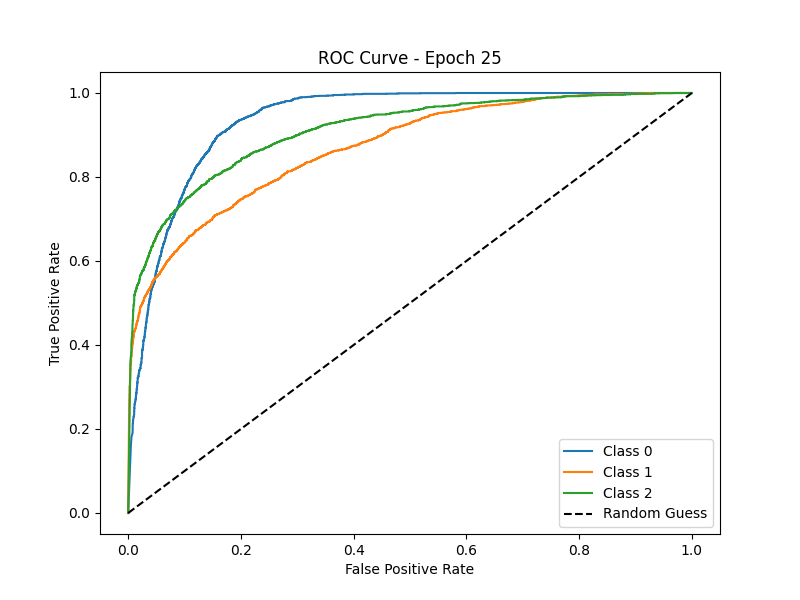

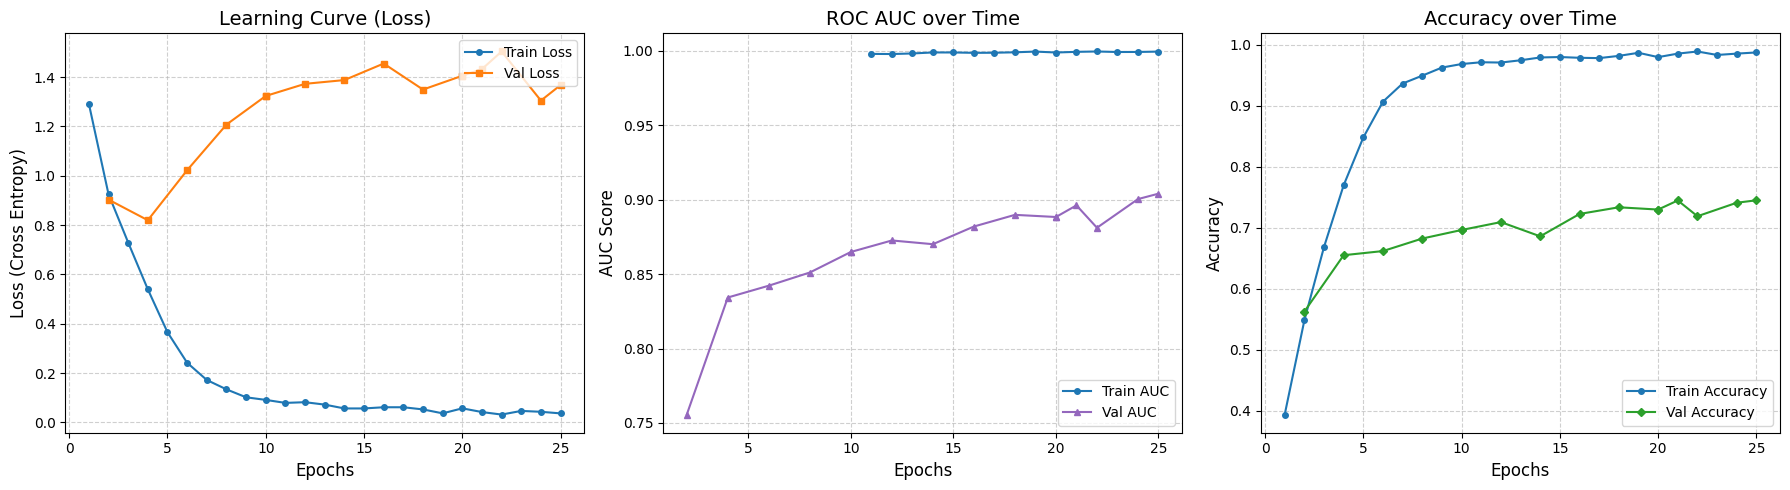

In [4]:
print(f"Fetching Final Results from MLflow Run: {BEST_RUN_ID}\n")

def fetch_metric(metric_name):
    try:
        history = client.get_metric_history(BEST_RUN_ID, metric_name)
        return [m.step for m in history], [m.value for m in history]
    except Exception:
        return [], []

# Fetch metrics
epochs_tl, train_loss = fetch_metric("avg_loss")
epochs_vl, val_loss = fetch_metric("val_avg_loss")

epochs_ta, train_auc = fetch_metric("roc_auc")
epochs_va, val_auc = fetch_metric("val_roc_auc")

epochs_tacc, train_acc = fetch_metric("accuracy")
epochs_vacc, val_acc = fetch_metric("val_accuracy")

final_auc = val_auc[-1] if val_auc else "N/A"
final_acc = val_acc[-1] if val_acc else "N/A"

print(f"Final Validation ROC AUC: {final_auc:.4f}")
if final_acc != "N/A":
    print(f"Final Validation Accuracy: {final_acc:.4f}\n")

with tempfile.TemporaryDirectory() as tmp_dir:
    try:
        artifact_path = "validation_metrics/roc_curve_epoch_25.png" 
        local_path = client.download_artifacts(BEST_RUN_ID, artifact_path, tmp_dir)
        display(Image(filename=local_path))
    except Exception as e:
        print(f"Could not load the final ROC curve artifact: {e}")

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Loss
if train_loss and val_loss:
    axes[0].plot(epochs_tl, train_loss, label="Train Loss", color="tab:blue", marker="o", markersize=4)
    axes[0].plot(epochs_vl, val_loss, label="Val Loss", color="tab:orange", marker="s", markersize=4)
    axes[0].set_title("Learning Curve (Loss)", fontsize=14)
    axes[0].set_xlabel("Epochs", fontsize=12)
    axes[0].set_ylabel("Loss (Cross Entropy)", fontsize=12)
    axes[0].legend(loc="upper right")
    axes[0].grid(True, linestyle="--", alpha=0.6)

# Plot 2: ROC AUC
if train_auc and val_auc:
    axes[1].plot(epochs_ta, train_auc, label="Train AUC", color="tab:blue", marker="o", markersize=4)
    axes[1].plot(epochs_va, val_auc, label="Val AUC", color="tab:purple", marker="^", markersize=5)
    axes[1].set_title("ROC AUC over Time", fontsize=14)
    axes[1].set_xlabel("Epochs", fontsize=12)
    axes[1].set_ylabel("AUC Score", fontsize=12)
    axes[1].legend(loc="lower right")
    axes[1].grid(True, linestyle="--", alpha=0.6)

# Plot 3: Accuracy
if train_acc and val_acc:
    axes[2].plot(epochs_tacc, train_acc, label="Train Accuracy", color="tab:blue", marker="o", markersize=4)
    axes[2].plot(epochs_vacc, val_acc, label="Val Accuracy", color="tab:green", marker="D", markersize=4)
    axes[2].set_title("Accuracy over Time", fontsize=14)
    axes[2].set_xlabel("Epochs", fontsize=12)
    axes[2].set_ylabel("Accuracy", fontsize=12)
    axes[2].legend(loc="lower right")
    axes[2].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## Now the demo run to see how things are working under the hood

In [ ]:
# Initialize Hydra and load the config
with initialize(version_base=None, config_path=f"../configs"):
    # Freeze the exact configuration used for this task via overrides
    cfg = compose(
        config_name="config", 
        overrides=[
            "model=efficient_net_b2_deeplense_classify",
            "dataset=deeplense_classify",
            "training.epochs=5",
            "sampling.sample_every_n_epochs=1",
            "experiment_name=demo_task1"
        ]
    )

print("Active Configuration Locked For Task 1:")
print(f"Model: {cfg.model.name} ({cfg.model.type})")
print(f"Dataset: {cfg.dataset.name}")
print(f"Epochs: {cfg.training.epochs}")

Active Configuration Locked For Task 1:
Model: efficient_net_b2 (classifier)
Dataset: deeplense_classify
Epochs: 5


In [8]:
from src.data import get_dataloaders, get_datasets, get_stats as get_stats_fn
from src.data.config import DataConfig
from src.models import get_model
from src.training.trainer import Trainer
from src.metrics import get_metric

# Load Data
data_config = DataConfig(**cfg.dataset)
train_dataset, test_dataset = get_datasets(data_config)
train_loader, test_loader = get_dataloaders(data_config)
get_stats = get_stats_fn(data_config)

# Load Model
model = get_model(cfg)

# Load Metrics
metrics = {}
for metric_cfg in cfg.model.metrics.values():
    metrics[metric_cfg.name] = get_metric(metric_cfg, cfg)

# Setup Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.training.lr)

# Initialize Trainer
trainer = Trainer(
    model=model,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    test_dataset=test_dataset,
    optimizer=optimizer,
    get_stats=get_stats,
    config=cfg,
    start_epoch=1,
    metrics=metrics
)

Loading dataset: deeplense_classify
Loading dataset: deeplense_classify
Trainer initialized for mode: CLASSIFIER
EMA enabled with decay rate: 0.9999


Fetching a fixed sample batch from the dataloader...


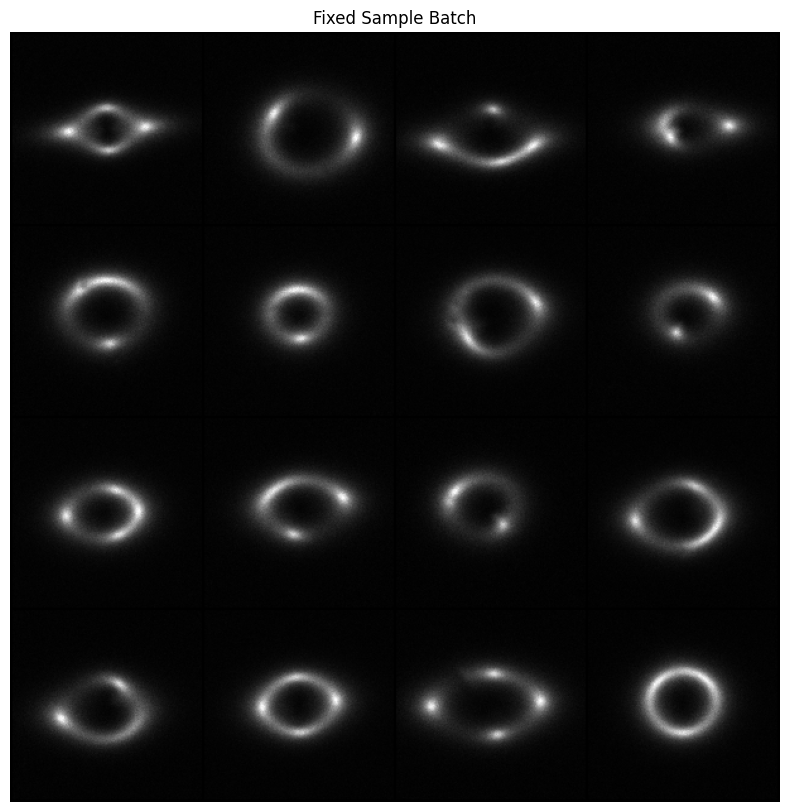

In [9]:
# Visualize what the model is about to see
print("Fetching a fixed sample batch from the dataloader...")
trainer.plot_fixed_batch()

In [10]:
# Start the MLflow run
mlflow.set_experiment(cfg.experiment_name)

with mlflow.start_run() as run:
    run_id = run.info.run_id
    print(f"Started MLflow Run ID: {run_id}")
    
    # Run short 2-epoch demo
    trainer.train()
    
print("Demonstration training complete!")

2026/03/21 17:27:37 INFO mlflow.tracking.fluent: Experiment with name 'demo_task1' does not exist. Creating a new experiment.


Started MLflow Run ID: 5212b76acc804a15bd4f5dbd98d6ec70
Starting training from epoch 1...


Epoch 1: 100%|██████████| 469/469 [02:26<00:00,  3.20it/s, loss=1.04] 


Epoch 1 - accuracy: 0.3810
Epoch 1 - roc_auc: 0.5536
Epoch 1 - Average loss: 1.2935


val_1: 100%|██████████| 118/118 [00:08<00:00, 13.71it/s]


...

Validation - Epoch 5 - accuracy: 0.6236
Validation - Epoch 5 - roc_auc: 0.8137
Logged ROC curve for epoch 5 to MLFlow
Average validation loss: 0.9519634888333789
Logged checkpoints for epoch 5 to MLFlow


2026/03/21 17:40:21 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/21 17:40:21 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/03/21 17:40:35 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Final EMA model saved in MLFlow model format
Logged checkpoints for epoch 5 to MLFlow


val_5: 100%|██████████| 118/118 [00:08<00:00, 13.70it/s]


Validation - Epoch 5 - accuracy: 0.6236
Validation - Epoch 5 - roc_auc: 0.8137
Logged ROC curve for epoch 5 to MLFlow
Average validation loss: 0.9519634888333789
Training complete.
Demonstration training complete!


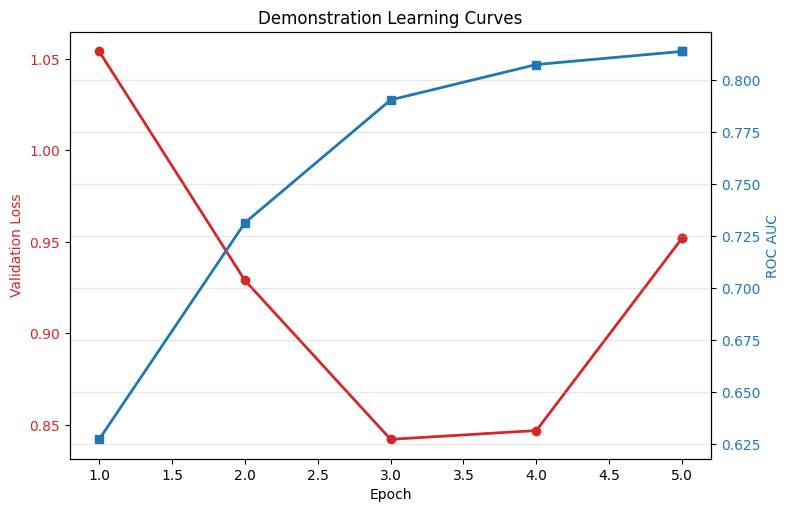

In [11]:
# Fetch the metric history for the run we just completed
client = mlflow.tracking.MlflowClient()

# Extract Validation Loss and ROC AUC
try:
    loss_history = client.get_metric_history(run_id, "val_avg_loss")
    auc_history = client.get_metric_history(run_id, "val_roc_auc")
    
    epochs = [m.step for m in loss_history]
    losses = [m.value for m in loss_history]
    aucs = [m.value for m in auc_history]

    # Plot the learning curves
    fig, ax1 = plt.subplots(figsize=(8, 5))

    color = 'tab:red'
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Validation Loss', color=color)
    ax1.plot(epochs, losses, color=color, marker='o', linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  
    color = 'tab:blue'
    ax2.set_ylabel('ROC AUC', color=color)  
    ax2.plot(epochs, aucs, color=color, marker='s', linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()  
    plt.title("Demonstration Learning Curves")
    plt.grid(True, alpha=0.3)
    plt.show()
except Exception as e:
    print(f"Could not fetch metric history: {e}")

Latest ROC Curve from MLflow Artifacts:


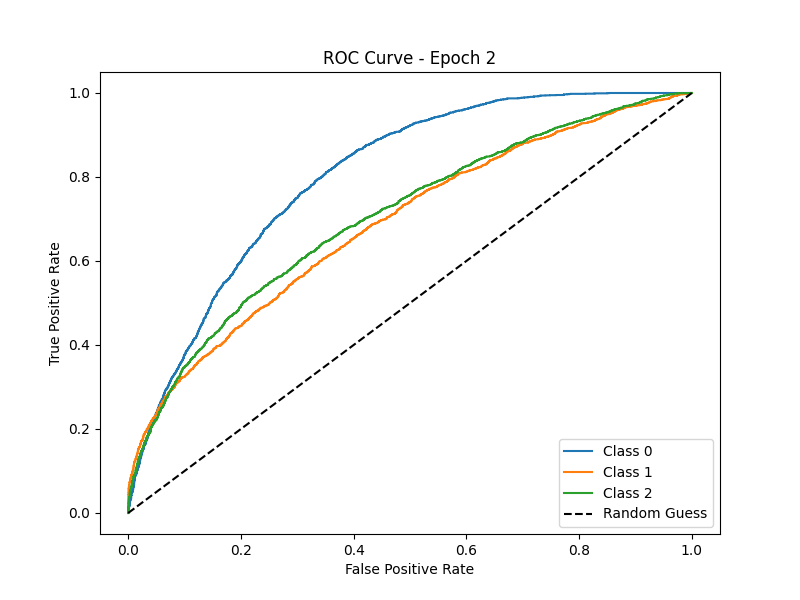

In [12]:
# Download the ROC curve image generated by the trainer and display it directly
import tempfile

with tempfile.TemporaryDirectory() as tmp_dir:
    # Download the specific artifact
    artifact_path = "validation_metrics/roc_curve_epoch_2.png"
    local_path = client.download_artifacts(run_id, artifact_path, tmp_dir)
    
    print("Latest ROC Curve from MLflow Artifacts:")
    display(Image(filename=local_path))